In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns       
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import torch 
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import json
from io import StringIO




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\joven\miniconda3\envs\setfit_clean\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\joven\miniconda3\envs\setfit_clean\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "c:\Users\joven\miniconda3\envs\setfit_clean\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\joven\miniconda3\envs\setfit_clean\lib\site-packages\traitlets\config\application.py", line 1075, in l

In [9]:
#Load the datasets

price_path_0 = r"C:\Users\joven\Documents\ML Projects\IMC-Prosperity-4\Round_3\csv_data\prices_round_3_day_0.csv"
trades_path_0 = r"C:\Users\joven\Documents\ML Projects\IMC-Prosperity-4\Round_3\csv_data\trades_round_3_day_0.csv"

price_path_1 = r"C:\Users\joven\Documents\ML Projects\IMC-Prosperity-4\Round_3\csv_data\prices_round_3_day_1.csv"
trades_path_1 = r"C:\Users\joven\Documents\ML Projects\IMC-Prosperity-4\Round_3\csv_data\trades_round_3_day_1.csv"

price_path_2 = r"C:\Users\joven\Documents\ML Projects\IMC-Prosperity-4\Round_3\csv_data\prices_round_3_day_2.csv"
trades_path_2 = r"C:\Users\joven\Documents\ML Projects\IMC-Prosperity-4\Round_3\csv_data\trades_round_3_day_2.csv"


prices_data_01 = pd.read_csv(price_path_1, sep=";")
trades_data_01 = pd.read_csv(trades_path_1, sep=";")
prices_data_02 = pd.read_csv(price_path_2, sep=";")
trades_data_02 = pd.read_csv(trades_path_2, sep=";")
prices_data_0 = pd.read_csv(price_path_0, sep=";")
trades_data_0 = pd.read_csv(trades_path_0, sep=";")



print(prices_data_01.shape[0])
print(trades_data_01.shape[0])

trades_data_01.head(40)

120000
1407


,timestamp,buyer,seller,symbol,currency,price,quantity
0,4500,NaN,NaN,VEV_5400,XIRECS,18.0,2
1,4500,NaN,NaN,VEV_5500,XIRECS,8.0,2
2,4500,NaN,NaN,VEV_6000,XIRECS,0.0,2
3,4500,NaN,NaN,VEV_6500,XIRECS,0.0,2
4,5100,NaN,NaN,HYDROGEL_PACK,XIRECS,9960.0,4
5,5300,NaN,NaN,VEV_4000,XIRECS,1264.0,2
6,6100,NaN,NaN,VELVETFRUIT_EXTRACT,XIRECS,5255.0,3
7,6200,NaN,NaN,HYDROGEL_PACK,XIRECS,9955.0,5
8,9400,NaN,NaN,VELVETFRUIT_EXTRACT,XIRECS,5244.0,8
9,9600,NaN,NaN,VEV_5400,XIRECS,16.0,4


In [10]:
# split VELVETFRUIT_EXTRACT and HYDROGEL_PACK data
prices_data_01_fruit = prices_data_01[prices_data_01['product'] == 'VELVETFRUIT_EXTRACT'].drop(columns=['product']).copy()
prices_data_01_gel = prices_data_01[prices_data_01['product'] == 'HYDROGEL_PACK'].drop(columns=['product']).copy()
prices_data_02_fruit = prices_data_02[prices_data_02['product'] == 'VELVETFRUIT_EXTRACT'].drop(columns=['product']).copy()
prices_data_02_gel = prices_data_02[prices_data_02['product'] == 'HYDROGEL_PACK'].drop(columns=['product']).copy()
prices_data_0_fruit = prices_data_0[prices_data_0['product'] == 'VELVETFRUIT_EXTRACT'].drop(columns=['product']).copy() 
prices_data_0_gel = prices_data_0[prices_data_0['product'] == 'HYDROGEL_PACK'].drop(columns=['product']).copy()  

trades_data_01_fruit = trades_data_01[trades_data_01['symbol'] == 'VELVETFRUIT_EXTRACT'].drop(columns=['symbol']).copy()
trades_data_01_gel = trades_data_01[trades_data_01['symbol'] == 'HYDROGEL_PACK'].drop(columns=['symbol']).copy()
trades_data_02_fruit = trades_data_02[trades_data_02['symbol'] == 'VELVETFRUIT_EXTRACT'].drop(columns=['symbol']).copy()
trades_data_02_gel = trades_data_02[trades_data_02['symbol'] == 'HYDROGEL_PACK'].drop(columns=['symbol']).copy()
trades_data_0_fruit = trades_data_0[trades_data_0['symbol'] == 'VELVETFRUIT_EXTRACT'].drop(columns=['symbol']).copy()
trades_data_0_gel = trades_data_0[trades_data_0['symbol'] == 'HYDROGEL_PACK'].drop(columns=['symbol']).copy()


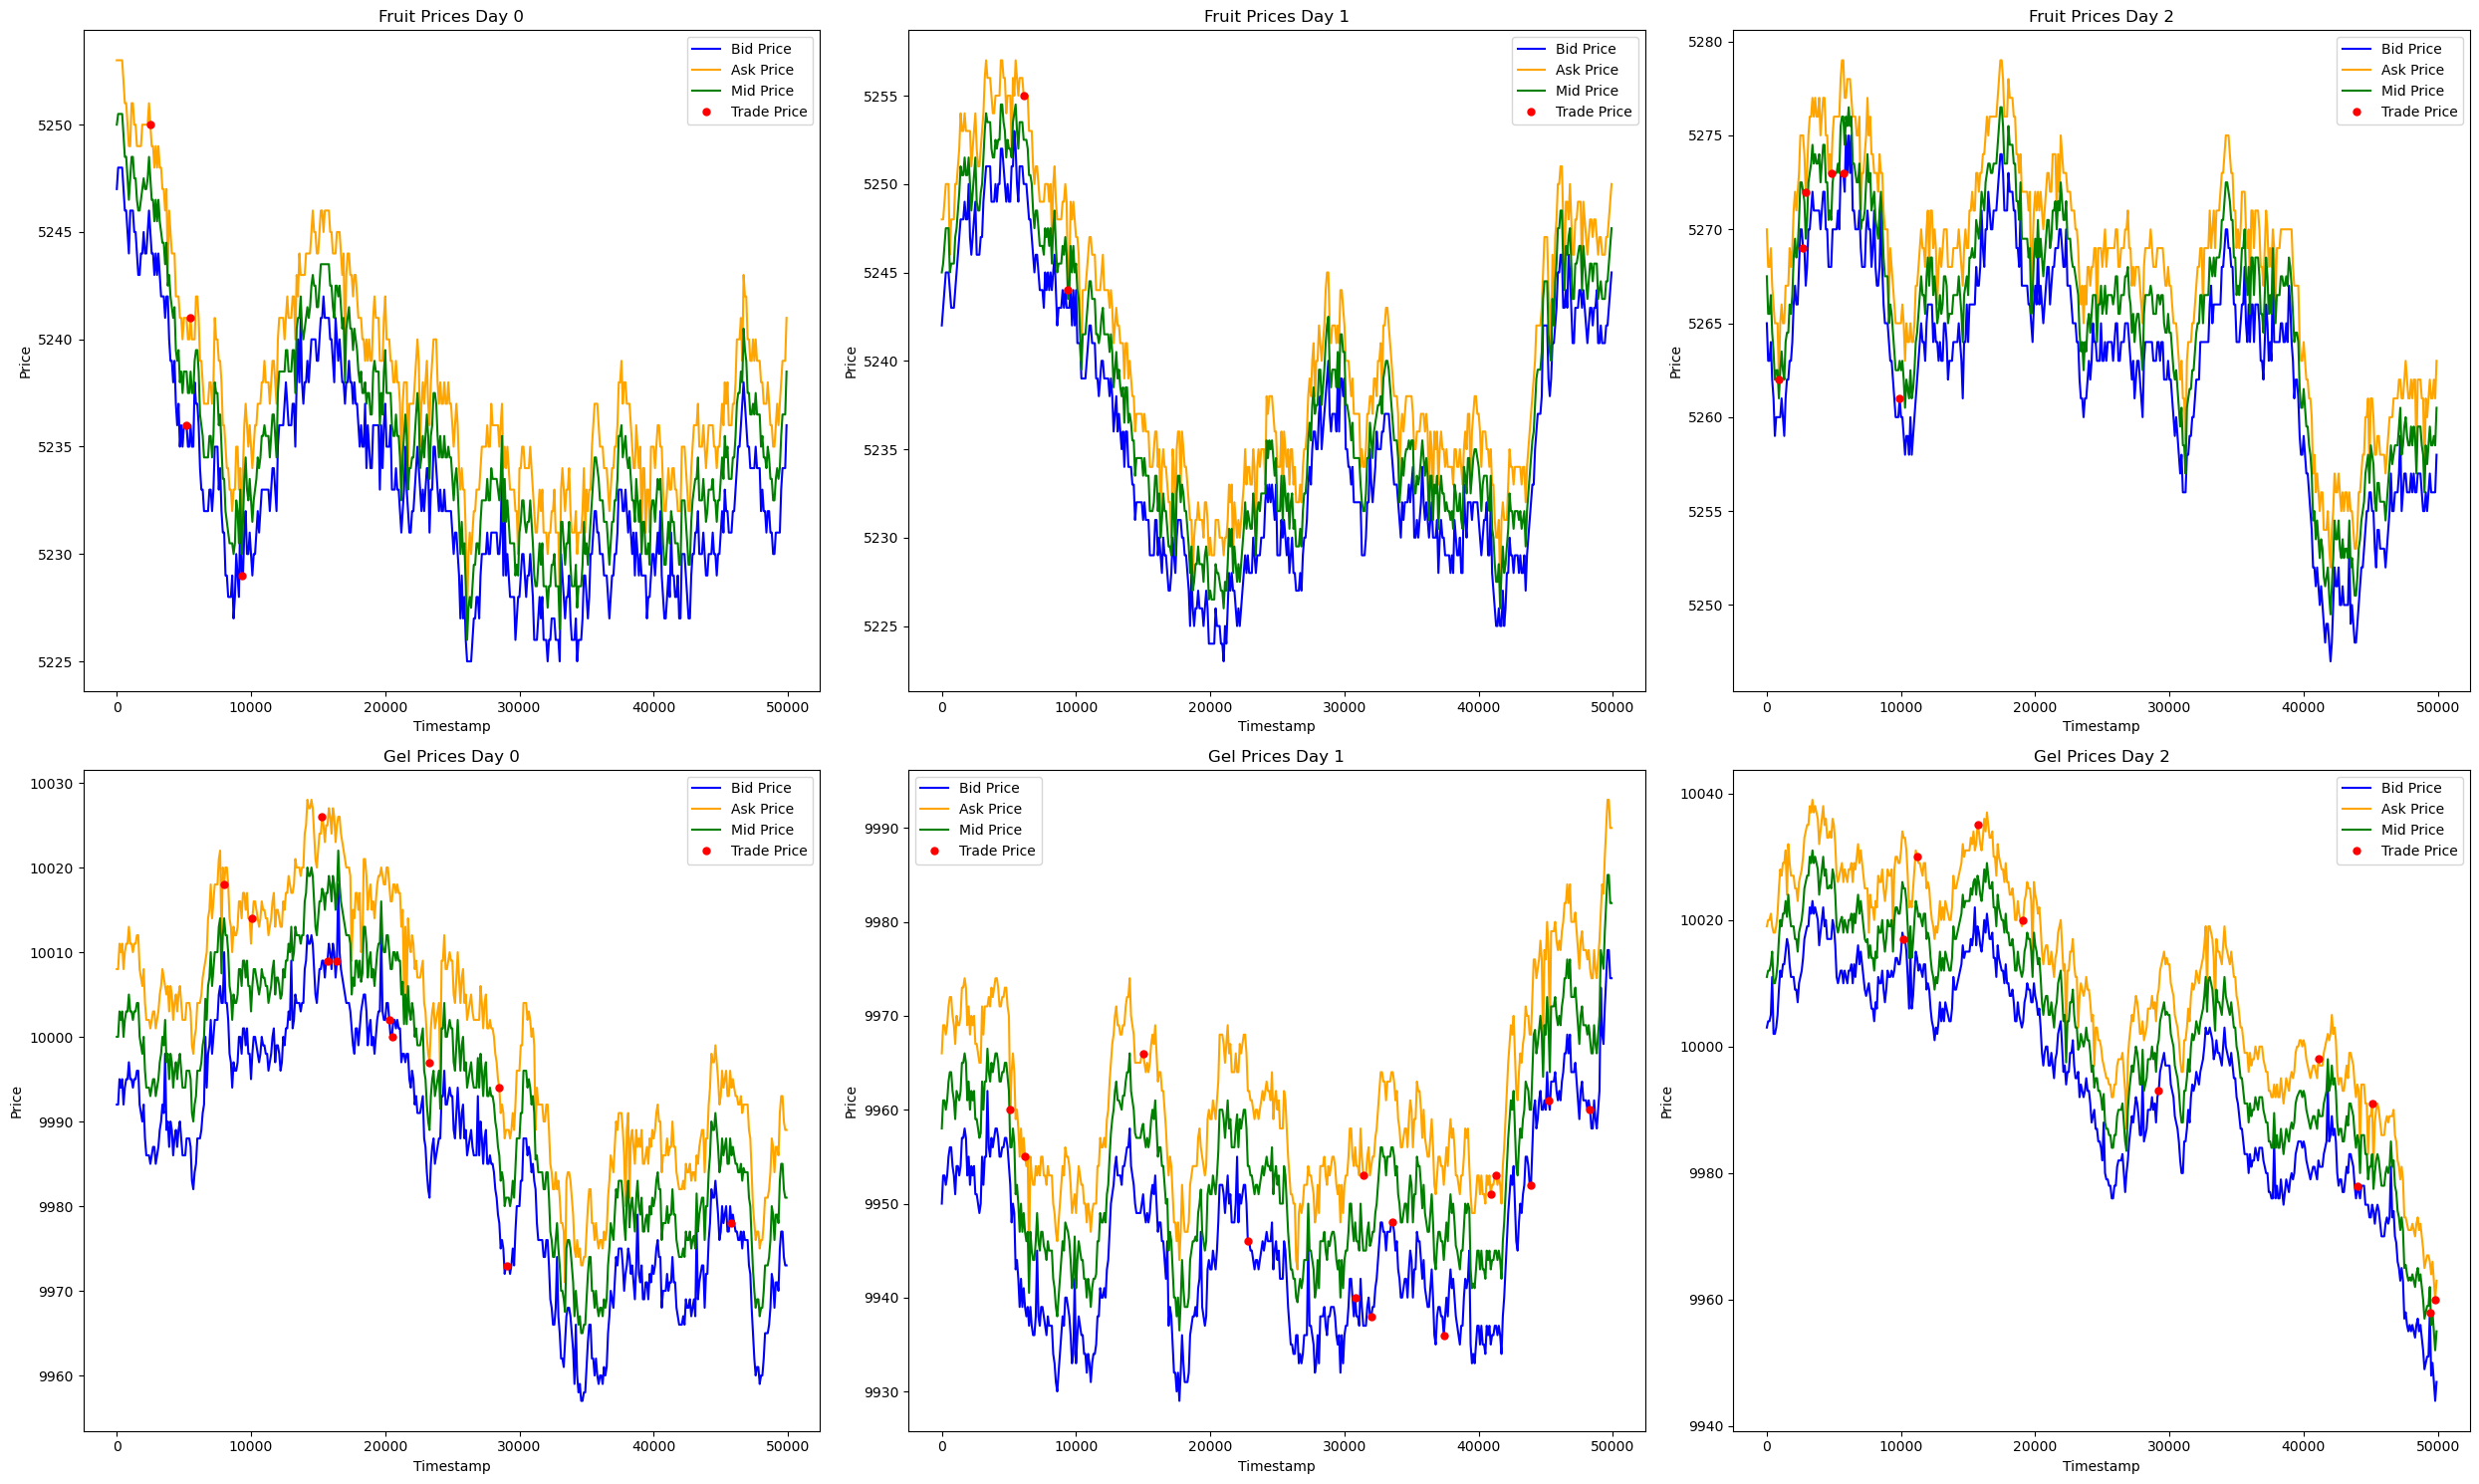

In [18]:
fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(25, 15))


fruit_pv = 500

#filter trades up to fruit_pv
trades_data_01_fruit = trades_data_01_fruit[trades_data_01_fruit["timestamp"] <= fruit_pv*100]
trades_data_02_fruit = trades_data_02_fruit[trades_data_02_fruit["timestamp"] <= fruit_pv*100]
trades_data_0_fruit = trades_data_0_fruit[trades_data_0_fruit["timestamp"] <= fruit_pv*100]

#friut day 0
ax1.plot(prices_data_0_fruit["timestamp"][:fruit_pv], prices_data_0_fruit["bid_price_1"][:fruit_pv], label="Bid Price", color="blue")
ax1.plot(prices_data_0_fruit["timestamp"][:fruit_pv], prices_data_0_fruit["ask_price_1"][:fruit_pv], label="Ask Price", color="orange")
ax1.plot(prices_data_0_fruit["timestamp"][:fruit_pv], prices_data_0_fruit["mid_price"][:fruit_pv  ], label="Mid Price", color="green")
ax1.plot(trades_data_0_fruit["timestamp"][:fruit_pv], trades_data_0_fruit["price"][:fruit_pv], label="Trade Price", color="red", marker="o", linestyle="None", markersize=5)
ax1.set_title("Fruit Prices Day 0")
ax1.set_xlabel("Timestamp")
ax1.set_ylabel("Price")
ax1.legend()


# fruit day 1

ax2.plot(prices_data_01_fruit["timestamp"][:fruit_pv], prices_data_01_fruit["bid_price_1"][:fruit_pv], label="Bid Price", color="blue")
ax2.plot(prices_data_01_fruit["timestamp"][:fruit_pv], prices_data_01_fruit["ask_price_1"][:fruit_pv], label="Ask Price", color="orange")
ax2.plot(prices_data_01_fruit["timestamp"][:fruit_pv], prices_data_01_fruit["mid_price"][:fruit_pv  ], label="Mid Price", color="green")
ax2.plot(trades_data_01_fruit["timestamp"][:fruit_pv], trades_data_01_fruit["price"][:fruit_pv], label="Trade Price", color="red", marker="o", linestyle="None", markersize=5)
ax2.set_title("Fruit Prices Day 1")
ax2.set_xlabel("Timestamp")
ax2.set_ylabel("Price")
ax2.legend()

# fruit day 2
ax3.plot(prices_data_02_fruit["timestamp"][:fruit_pv], prices_data_02_fruit["bid_price_1"][:fruit_pv], label="Bid Price", color="blue")
ax3.plot(prices_data_02_fruit["timestamp"][:fruit_pv], prices_data_02_fruit["ask_price_1"][:fruit_pv], label="Ask Price", color="orange")
ax3.plot(prices_data_02_fruit["timestamp"][:fruit_pv], prices_data_02_fruit["mid_price"][:fruit_pv  ], label="Mid Price", color="green")
ax3.plot(trades_data_02_fruit["timestamp"][:fruit_pv], trades_data_02_fruit["price"][:fruit_pv], label="Trade Price", color="red", marker="o", linestyle="None", markersize=5)
ax3.set_title("Fruit Prices Day 2")
ax3.set_xlabel("Timestamp")
ax3.set_ylabel("Price")
ax3.legend()



gel_pv = 500

#filter trades up to gel_pv
trades_data_01_gel = trades_data_01_gel[trades_data_01_gel["timestamp"] <= gel_pv*100]
trades_data_02_gel = trades_data_02_gel[trades_data_02_gel["timestamp"] <= gel_pv*100]
trades_data_0_gel = trades_data_0_gel[trades_data_0_gel["timestamp"] <= gel_pv*100]

#gel day 0
ax4.plot(prices_data_0_gel["timestamp"][:gel_pv], prices_data_0_gel["bid_price_1"][:gel_pv], label="Bid Price", color="blue")
ax4.plot(prices_data_0_gel["timestamp"][:gel_pv], prices_data_0_gel["ask_price_1"][:gel_pv], label="Ask Price", color="orange")
ax4.plot(prices_data_0_gel["timestamp"][:gel_pv], prices_data_0_gel["mid_price"][:gel_pv], label="Mid Price ", color="green")
ax4.plot(trades_data_0_gel["timestamp"][:gel_pv], trades_data_0_gel ["price"][:gel_pv], label="Trade Price", color="red", marker="o", linestyle="None", markersize=5)   
ax4.set_title("Gel Prices Day 0")
ax4.set_xlabel("Timestamp")
ax4.set_ylabel("Price")
ax4.legend()

#GEL DAY -1
ax5.plot(prices_data_01_gel["timestamp"][:gel_pv], prices_data_01_gel["bid_price_1"][:gel_pv], label="Bid Price", color="blue")
ax5.plot(prices_data_01_gel["timestamp"][:gel_pv], prices_data_01_gel["ask_price_1"][:gel_pv], label="Ask Price", color="orange")
ax5.plot(prices_data_01_gel["timestamp"][:gel_pv], prices_data_01_gel["mid_price"][:gel_pv], label="Mid Price", color="green")
ax5.plot(trades_data_01_gel["timestamp"][:gel_pv], trades_data_01_gel["price"][:gel_pv], label="Trade Price", color="red", marker="o", linestyle="None", markersize=5)
ax5.set_title("Gel Prices Day 1")
ax5.set_xlabel("Timestamp")
ax5.set_ylabel("Price")
ax5.legend()

# gel day -2
ax6.plot(prices_data_02_gel["timestamp"][:gel_pv], prices_data_02_gel["bid_price_1"][:gel_pv], label="Bid Price", color="blue")
ax6.plot(prices_data_02_gel["timestamp"][:gel_pv], prices_data_02_gel["ask_price_1"][:gel_pv], label="Ask Price", color="orange")
ax6.plot(prices_data_02_gel["timestamp"][:gel_pv], prices_data_02_gel["mid_price"][:gel_pv], label="Mid Price", color="green")
ax6.plot(trades_data_02_gel["timestamp"][:gel_pv], trades_data_02_gel["price"][:gel_pv], label="Trade Price", color="red", marker="o", linestyle="None", markersize=5)
ax6.set_title("Gel Prices Day 2")
ax6.set_xlabel("Timestamp")
ax6.set_ylabel("Price")
ax6.legend()


plt.tight_layout()
plt.show()
